In [1]:
import tensorly as tl
import mne
import tensorly as tl
import os

backend = 'numpy'
os.environ['TENSORLY_BACKEND'] = backend
tl.set_backend(backend)
mne.set_log_level('ERROR')

print(mne.get_config_path())
print(mne.get_config('MNE_DATA'))
print(mne.get_config('MOABB_RESULTS'))
print(tl.get_backend())

/user/leuven/352/vsc35289/.mne/mne-python.json
/scratch/leuven/352/vsc35289/mne_data
/data/leuven/352/vsc35289/moabb_results
numpy


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

paradigm = P300(resample=48)
datasets = [BNCI2014_008(), BNCI2015_003()]


In [3]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel

bttda = GreedyBTTDA(
    max_blocks=20,
    truncate=False,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    n_jobs=8,
    select=True
)

In [4]:
import tensorly as tl
import pandas as pd

select_info = []
train_info = []
for dataset in datasets:
    for subject in dataset.subject_list:
        epochs, labels, meta = paradigm.get_data(
            dataset=dataset, 
             subjects=[subject],
             return_epochs=True
        )
        for session in meta['session'].unique():
            idc = meta['session'] == session
            epochs_ses = epochs[idc]
            labels_ses = labels[idc]
            meta_ses = meta[idc]

            X = epochs_ses.get_data()
            X = tl.tensor(X)
            y = labels_ses

            print(f'dataset={dataset} subject={subject} session={session}')
            bttda.fit(X,y, test=False)
            subj_select_info = pd.DataFrame(bttda.model_select_info_) 
            subj_select_info['dataset'] = dataset.code
            subj_select_info['subject'] = subject
            subj_select_info['session'] = session
            subj_train_info = pd.DataFrame(bttda.train_info_)
            subj_train_info['dataset'] = dataset.code
            subj_train_info['subject'] = subject
            subj_train_info['session'] = session
            select_info.append(subj_select_info.reset_index())
            train_info.append(subj_train_info.reset_index())
select_info = pd.concat(select_info, ignore_index=True)
train_info = pd.concat(train_info, ignore_index=True)

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  4200 events (all good), 0 – 1 s, baseline off, ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


subject=1 session=0
Model selection block 1/20...
rank=(1, 1)
Model selection block 2/20...
rank=(8, 8)
Model selection block 3/20...
rank=(8, 8)
Model selection block 4/20...
rank=(8, 8)
Model selection block 5/20...
rank=(4, 4)
Model selection block 6/20...
rank=(8, 8)
Model selection block 7/20...
rank=(8, 8)
Model selection block 8/20...
rank=(4, 4)
Model selection block 9/20...
rank=(4, 4)
Model selection block 10/20...
rank=(8, 8)
Model selection block 11/20...
rank=(2, 2)
Model selection block 12/20...
rank=(4, 4)
Model selection block 13/20...
rank=(8, 8)
Model selection block 14/20...
rank=(8, 8)
Model selection block 15/20...
rank=(2, 2)
Model selection block 16/20...
rank=(8, 8)
Model selection block 17/20...
rank=(1, 1)
Model selection block 18/20...
rank=(1, 1)
Model selection block 19/20...
rank=(8, 8)
Model selection block 20/20...
rank=(1, 1)
Selected model with ranks [(1, 1), (8, 8), (8, 8), (8, 8), (4, 4), (8, 8), (8, 8), (4, 4), (4, 4), (8, 8), (2, 2), (4, 4), (8, 8)

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  4200 events (all good), 0 – 1 s, baseline off, ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


subject=2 session=0
Model selection block 1/20...
rank=(8, 8)
Model selection block 2/20...
rank=(1, 1)
Model selection block 3/20...
rank=(1, 1)
Model selection block 4/20...
rank=(8, 8)
Model selection block 5/20...
rank=(8, 8)
Model selection block 6/20...
rank=(4, 4)
Model selection block 7/20...
rank=(1, 1)
Model selection block 8/20...
rank=(8, 8)
Model selection block 9/20...
rank=(8, 8)
Model selection block 10/20...
rank=(4, 4)
Model selection block 11/20...
rank=(8, 8)
Model selection block 12/20...
rank=(4, 4)
Model selection block 13/20...
rank=(8, 8)
Model selection block 14/20...
rank=(8, 8)
Model selection block 15/20...
rank=(8, 8)
Model selection block 16/20...
rank=(4, 4)
Model selection block 17/20...
rank=(2, 2)
Model selection block 18/20...
rank=(4, 4)
Model selection block 19/20...
rank=(1, 1)
Model selection block 20/20...
rank=(8, 8)
Selected model with ranks [(8, 8), (1, 1), (1, 1), (8, 8), (8, 8), (4, 4), (1, 1), (8, 8), (8, 8), (4, 4), (8, 8), (4, 4), (8, 8)

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  4200 events (all good), 0 – 1 s, baseline off, ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


...

subject=8 session=0
Model selection block 1/20...
rank=(1, 1)
Model selection block 2/20...
rank=(4, 4)
Model selection block 3/20...
rank=(4, 4)
Model selection block 4/20...
rank=(4, 4)
Model selection block 5/20...
rank=(2, 2)
Model selection block 6/20...
rank=(2, 2)
Model selection block 7/20...
rank=(8, 8)
Model selection block 8/20...
rank=(1, 1)
Model selection block 9/20...
rank=(2, 2)
Model selection block 10/20...
rank=(2, 2)
Model selection block 11/20...
rank=(2, 2)
Model selection block 12/20...
rank=(2, 2)
Model selection block 13/20...
rank=(1, 1)
Model selection block 14/20...
rank=(1, 1)
Model selection block 15/20...
rank=(2, 2)
Model selection block 16/20...
rank=(2, 2)
Model selection block 17/20...
rank=(1, 1)
Model selection block 18/20...
rank=(1, 1)
Model selection block 19/20...
rank=(1, 1)
Model selection block 20/20...
rank=(2, 2)
Selected model with ranks [(1, 1), (4, 4), (4, 4), (4, 4), (2, 2), (2, 2), (8, 8), (1, 1), (2, 2), (2, 2), (2, 2), (2, 2), (1, 1)

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  900 events (all good), 0 – 0.800781 s, baseline off, ~11.3 MB, data loaded,
 'Target': 150
 'NonTarget': 750>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  900 events (all good), 0 – 0.800781 s, baseline off, ~11.3 MB, data loaded,
 'Target': 150
 'NonTarget': 750>
  warn(f"warnEpochs {epochs}")


subject=9 session=0
Model selection block 1/20...
rank=(1, 1)
Model selection block 2/20...
rank=(2, 2)
Model selection block 3/20...
rank=(1, 1)
Model selection block 4/20...
rank=(1, 1)
Model selection block 5/20...
rank=(8, 8)
Model selection block 6/20...
rank=(1, 1)
Model selection block 7/20...
rank=(2, 2)
Model selection block 8/20...
rank=(1, 1)
Model selection block 9/20...
rank=(2, 2)
Model selection block 10/20...
rank=(1, 1)
Model selection block 11/20...
rank=(1, 1)
Model selection block 12/20...
rank=(4, 4)
Model selection block 13/20...
rank=(8, 8)
Model selection block 14/20...
rank=(1, 1)
Model selection block 15/20...
rank=(4, 4)
Model selection block 16/20...
rank=(1, 1)
Model selection block 17/20...
rank=(4, 4)
Model selection block 18/20...
rank=(1, 1)
Model selection block 19/20...
rank=(2, 2)
Model selection block 20/20...
rank=(2, 2)
Selected model with ranks [(1, 1), (2, 2), (1, 1), (1, 1), (8, 8), (1, 1), (2, 2), (1, 1), (2, 2), (1, 1), (1, 1), (4, 4), (8, 8)

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  900 events (all good), 0 – 0.800781 s, baseline off, ~11.3 MB, data loaded,
 'Target': 150
 'NonTarget': 750>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  900 events (all good), 0 – 0.800781 s, baseline off, ~11.3 MB, data loaded,
 'Target': 150
 'NonTarget': 750>
  warn(f"warnEpochs {epochs}")


subject=10 session=0
Model selection block 1/20...
rank=(1, 1)
Model selection block 2/20...
rank=(2, 2)
Model selection block 3/20...
rank=(2, 2)
Model selection block 4/20...
rank=(4, 4)
Model selection block 5/20...
rank=(4, 4)
Model selection block 6/20...
rank=(1, 1)
Model selection block 7/20...
rank=(4, 4)
Model selection block 8/20...
rank=(1, 1)
Model selection block 9/20...
rank=(4, 4)
Model selection block 10/20...
rank=(1, 1)
Model selection block 11/20...
rank=(1, 1)
Model selection block 12/20...
rank=(2, 2)
Model selection block 13/20...
rank=(2, 2)
Model selection block 14/20...
rank=(1, 1)
Model selection block 15/20...
rank=(2, 2)
Model selection block 16/20...
rank=(1, 1)
Model selection block 17/20...
rank=(1, 1)
Model selection block 18/20...
rank=(1, 1)
Model selection block 19/20...
rank=(1, 1)
Model selection block 20/20...
rank=(1, 1)
Selected model with ranks [(1, 1), (2, 2), (2, 2), (4, 4), (4, 4), (1, 1), (4, 4), (1, 1), (4, 4), (1, 1), (1, 1), (2, 2), (2, 2

In [5]:
select_info.to_csv('block_erp_select.csv')
select_info

,block,rank,fold,n_features_orig,n_features,hoda,train_score,val_score,dataset,subject,session
0,0,"(1, 1)",0,1,1,"HODA(init='random', max_iter=64, obj='tr', ran...",0.827570,0.813398,BNCI2014-008,1,0
1,0,"(2, 2)",0,4,2,"HODA(init='random', max_iter=64, obj='tr', ran...",0.816475,0.797469,BNCI2014-008,1,0
2,0,"(4, 4)",0,16,4,"HODA(init='random', max_iter=64, obj='tr', ran...",0.789328,0.767010,BNCI2014-008,1,0
3,0,"(8, 8)",0,64,23,"HODA(init='random', max_iter=64, obj='tr', ran...",0.835879,0.815418,BNCI2014-008,1,0
4,0,"(1, 1)",1,1,1,"HODA(init='random', max_iter=64, obj='tr', ran...",0.821217,0.842867,BNCI2014-008,1,0
...,...,...,...,...,...,...,...,...,...,...,...
7195,19,"(8, 8)",3,158,37,"HODA(init='random', max_iter=64, obj='tr', ran...",0.954156,0.874222,BNCI2015-003,10,0
7196,19,"(1, 1)",4,95,35,"HODA(init='random', max_iter=64, obj='tr', ran...",0.953208,0.889667,BNCI2015-003,10,0
7197,19,"(2, 2)",4,98,35,"HODA(init='random', max_iter=64, obj='tr', ran...",0.953160,0.888278,BNCI2015-003,10,0
7198,19,"(4, 4)",4,110,41,"HODA(init='random', max_iter=64, obj='tr', ran...",0.954118,0.884389,BNCI2015-003,10,0


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='block', ylabel='value'>

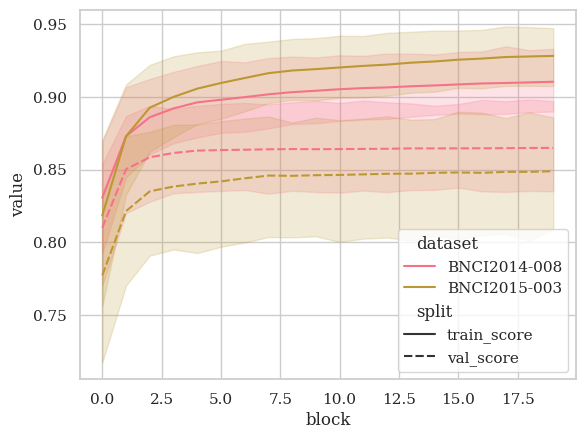

In [7]:
import seaborn as sns

idx = ['dataset', 'subject', 'session', 'block']
df = select_info.groupby(idx)[['train_score', 'val_score']].aggregate('mean')
df = df.melt(var_name='split', ignore_index=False)
df = df.reset_index()
sns.lineplot(data=df, x='block', y='value', style='split', hue='dataset')

In [11]:
train_info.to_csv('block_erp_train.csv')
train_info

,index,block,rank,F_tr,F_rt,mse,nmse,dataset,subject,session
0,0,1,"(1, 1)",0.000097,0.000193,1.066723e-10,0.999052,BNCI2014-008,1,0
1,1,2,"(8, 8)",0.000002,0.000278,9.920665e-11,0.929132,BNCI2014-008,1,0
2,2,3,"(8, 8)",0.000002,0.000293,9.610722e-11,0.900104,BNCI2014-008,1,0
3,3,4,"(8, 8)",0.000002,0.000304,8.891490e-11,0.832743,BNCI2014-008,1,0
4,4,5,"(4, 4)",0.000002,0.000310,8.819526e-11,0.826003,BNCI2014-008,1,0
...,...,...,...,...,...,...,...,...,...,...
355,15,16,"(1, 1)",0.000077,0.001721,3.192703e-11,0.898988,BNCI2015-003,10,0
356,16,17,"(1, 1)",0.000077,0.001721,3.191850e-11,0.898748,BNCI2015-003,10,0
357,17,18,"(1, 1)",0.000077,0.001723,3.183055e-11,0.896271,BNCI2015-003,10,0
358,18,19,"(1, 1)",0.000077,0.001724,3.177030e-11,0.894575,BNCI2015-003,10,0


/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/p

<Axes: xlabel='block', ylabel='nmse'>

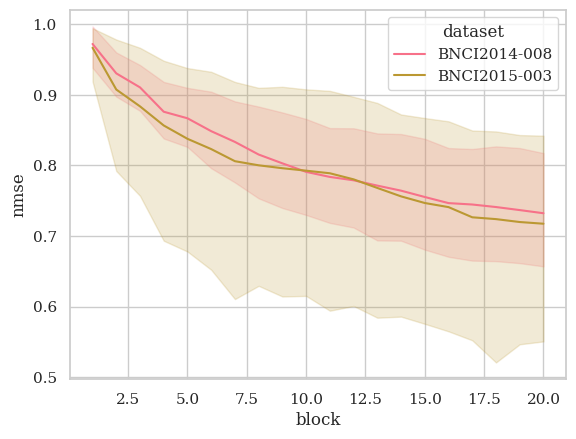

In [12]:
df = train_info.groupby(idx)
df = df['nmse'].aggregate('mean')
df = df.reset_index()
sns.lineplot(data=df, x='block',y='nmse', hue='dataset')